# **Turbo-Brainvoyager Network Interface - ROI statistics**

In this excersice you will learn the commands to get ROI data from Turbo-Brainvoyager (TBV) using the python network interface. You can download the python version of the TBV network inteface at this link: https://github.com/expyriment/expyriment-stash/tree/master/extras/expyriment_io_extras/tbvnetworkinterface

The TBV python network interface relies on the Expyriment package (https://github.com/expyriment/expyriment).


## 1. Connet to TBV using TCP-IP protocol

You need to define **HOST IP** of the PC running TBV and TBV listening **PORT** (check that in the in the master TBV settings) to start a TCP/IP connection. 

In [36]:
from expyriment_io_extras.tbvnetworkinterface import TbvNetworkInterface
import warnings
warnings.filterwarnings("ignore")

HOST = 'localhost'
PORT = 55555

# try to connect to TBV
try:
    TBV = TbvNetworkInterface(HOST, PORT)
    print('\nConnected to TBV.')
    print(f'HOST: {HOST}, PORT: {PORT}\n\n')

    # inspect available class methods
    for name in dir(TBV):
        if callable(getattr(TBV, name)):
            print(name)
            
except Exception as e:
    print(e)
    exit(1)


Connected to TBV.
HOST: localhost, PORT: 55555


DataError
RequestError
TimeoutError
__class__
__delattr__
__dir__
__eq__
__format__
__ge__
__getattribute__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__le__
__lt__
__ne__
__new__
__reduce__
__reduce_ex__
__repr__
__setattr__
__sizeof__
__str__
__subclasshook__
_send
_wait
close
connect
get_all_coords_of_voxels_of_roi
get_beta_maps
get_beta_of_roi
get_beta_of_voxel
get_contrast_maps
get_coord_of_voxel_of_roi
get_current_classifier_output
get_current_classifier_probability
get_current_nr_of_predictors
get_current_protocol_condition
get_current_time_point
get_detrended_instant_proxy_correlation
get_detrended_instant_proxy_correlation_at_time_point
get_detrended_mean_of_roi_at_time_point
get_detrended_partial_correlation
get_detrended_partial_correlation_at_time_point
get_detrended_pearson_correlation
get_detrended_pearson_correlation_at_time_point
get_detrended_value_of_roi
get_dims_of_functional_data
get_existing_detrended_m

## 2. Get ROI info and effect size

For this demo let's use the Faces and Houses sample dataset. Load the 'NK_FFA_PPA_MNI-1.tbvj' file, preload the provided **FFA_PPA_Rosenke_1region.voi** file using the 'Preload VOI' button and start the real-time processing. The provided VOI file contains bilateral FFA and PPA regions in MNI space defined from the Rosenke atlas (Rosenke et al. 2021). After starting the processing you can run this section of the notebook. Note that the preloaded VOIs will be automatically transformed to funtional space ROIs. If you ran the Faces and Houses exercise before you could also you a manully define a ROI based on the 'Houses vs Faces' contrast. This section of the code shows how to get ROI dimensions, mean ROI statistics and single voxel statistics for different experimental conditions. Check the dimensions of all provided subregions. Get average beta values of all provided subregions (only available during the real-time preprocessing). Check among the available functions of the network interface class how to print t-value of a voxel within the selected ROI. Contrast maps will be available to the network interface also at the end of the processing and when reloading previously preprocessd data.

In [2]:
nr_roi, rt = TBV.get_nr_of_rois()
print('TBV number of loaded ROI: ', nr_roi)


if nr_roi > 0:

    nr_voxels, rt = TBV.get_nr_of_voxels_of_roi(0) # needs the ROI index as input (0-based)
    print(f'Number of voxels of ROI {0}: ', nr_voxels)

    # get number of predictors of interest
    nr_predictors_of_interest = TBV.get_current_nr_of_predictors()[0] - TBV.get_nr_of_confound_predictors()[0]

    # get average ROI beta value for all conditions
    for i in range(nr_predictors_of_interest):
        
        mean_roi_beta, rt = TBV.get_beta_of_roi(0, i) # needs ROI index and condition index (0-based)
        print('\nCurrent time point: ', TBV.get_current_time_point()[0])
        print(f'Average beta of ROI {0} of conditions {i}: ', mean_roi_beta)

    
    # get coordinates of voxels of the current ROI 0
    coords = TBV.get_all_coords_of_voxels_of_roi(0)[0]
    #print(coords)

    # get current t-statstic at a predefined voxel of ROI 0 for the desired contrast
    # Contrast indexing follows the order that is visible in the contrast window in TBV
    voxel_tvalue = TBV.get_map_value_of_voxel(0,coords[0])[0] # needs coordinates of the voxel [x,y,z] and contrast map index (0-based)
    print(f'T stat at voxel {coords[0]}: {voxel_tvalue:.3f}')

else:
    print('No ROI available. Please load a ROI before running this section')


TBV number of loaded ROI:  1
Number of voxels of ROI 0:  10
T stat at voxel [25, 38, 8]: 3.422


## 3. ROI peak statistics

This section of the code prints out peak t-statistics for each ROI and a predefined contrast. Print out the peak statistics for each contrast as well. You can check among the available network calls how to get the number of available contrasts.

In [23]:
import numpy as np

nr_roi, rt = TBV.get_nr_of_rois()
print('TBV number of loaded ROI: ', nr_roi)

if nr_roi > 0:

    # get peak t-statistics for each ROI
    for i in range(nr_roi):
        
        # get coordinates of voxels of the current ROI 
        coords = TBV.get_all_coords_of_voxels_of_roi(i)[0]

        roi_tvalues = [TBV.get_map_value_of_voxel(0,current_coords)[0] for current_coords in coords] # getting stat value for the first contrast map

        # get the index of the absolute peak value
        peak_idx = np.argmax(np.abs(roi_tvalues))

        print(f'\nPeak T stat of ROI {i}: {roi_tvalues[peak_idx]:.3f}')
        print('Peak coordinates: ', coords[peak_idx])  

else:
    print('No ROI available. Please load a ROI before running this section')



TBV number of loaded ROI:  2

Peak T stat of ROI 0: 11.544
Peak coordinates:  [39, 42, 10]

Peak T stat of ROI 1: 2.655
Peak coordinates:  [23, 37, 8]


## 4. Display ROI and ROI pattern

It is possible to replicate the TBV visualisation of the current ROIs and statistical maps. The script below shows how to plot a slice of the functional data and overlay the region of interest. Following the same idea, you can try to plot region T-stat map (putting t-statistics at the voxel coordinate). Run this code at the end of the real-time processing.


TBV number of loaded ROI:  1
Functional data dimensions:  [64, 64, 30]
TBV TargetFolder:  C:/Users/assun/Downloads/TBV_FacesHouses/TBV_FacesHouses/target_MNI/
TBV FeedbackFolder:  NK_FFA_PPA
[24 42  9]


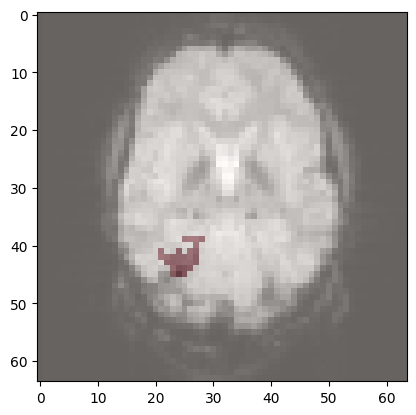

In [69]:
import matplotlib.pyplot as plt
from bvbabel import fmr

nr_roi, rt = TBV.get_nr_of_rois()
print('TBV number of loaded ROI: ', nr_roi)

func_dims =  TBV.get_dims_of_functional_data()[0]
print('Functional data dimensions: ', func_dims)

# get average functional image for display purposes using bvbabel
# retrieve the current FMR filename
target_folder, rt = TBV.get_target_folder()
print('TBV TargetFolder: ', target_folder)

project_name, rt = TBV.get_project_name()
print('TBV FeedbackFolder: ', progect_name)

fmr_filename = f'{target_folder}/{project_name}.fmr'

# read FMR data
hdr, fmr_data = fmr.read_fmr(fmr_filename)
avg_epi = np.transpose(np.mean(fmr_data,axis=3)[:,::-1,:],[1,0,2]) # average over time

if nr_roi > 0:

    # get coordinates of voxels of the current ROI 
    coords = TBV.get_all_coords_of_voxels_of_roi(0)[0]
    roi_centroid = np.mean(coords, axis=0).astype(int)
    print(roi_centroid)
    #roi_centroid[2]=29
    roi_mask = np.zeros(func_dims) 

    for coord in coords:
            roi_mask[coord[0], coord[1] ,coord[2]]=1

    roi_mask = np.transpose(roi_mask[::-1,:,:], [1,0,2])[:,::-1,:]

    fig, ax = plt.subplots()
    ax.imshow(avg_epi[:,:,roi_centroid[2]], cmap='gray')
    ax.imshow(roi_mask[:,:,roi_centroid[2]], alpha=0.4, cmap='Reds')

    # display ROI tmap

else:
    print('No ROI available. Please load a ROI before running this section')



## 5. Sync to TBV to get ROI statistics at a predefined time point and create feedback image

When running NF you might want to provide custom feedback to the participant at a certain time point. An ROI-based feedback is usually computed as average metric value within the ROI in a predefined time window, and showed continuously or intermittently. The code below shows how to sync to TBV and get feedback values and create a thermometer feedback display. The feedback timings defined here are supposed to work with the Faces and Houses example dataset. This code can run both during real-time processing or at the end of the process. Note that since the feedback computation is based on detrended average time course of the ROI, you should preload the ROI before running the processing. Try to setup the feedback timings for the EmoNF_7T neurofeedback run, creating the feedback image at the onset of the 'Feedback' block.

TBV Expected number of time points:  108
Saving feedback images toTBV TargetFolder:  C:/Users/assun/Downloads/TBV_FacesHouses/TBV_FacesHouses/target_MNI/


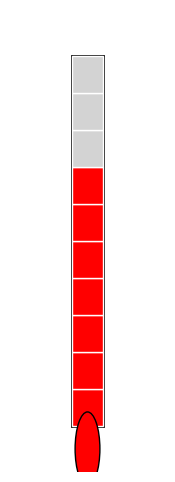

PSC detrended average BOLD in block 1: 0.6414782918989659


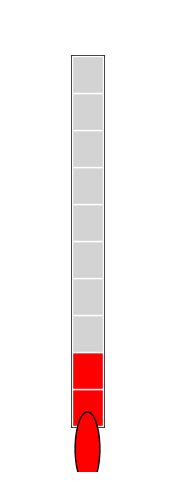

PSC detrended average BOLD in block 2: 0.19340136498212815


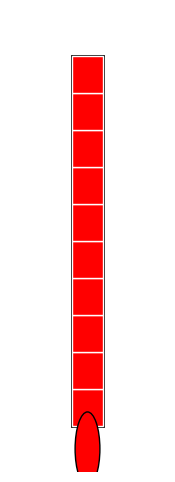

PSC detrended average BOLD in block 3: 1.5419795989990235


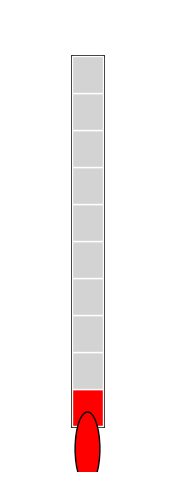

PSC detrended average BOLD in block 4: 0.007654798030853271


In [34]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_thermometer(level=5, max_level=10):
    fig, ax = plt.subplots(figsize=(2, 6))

    # Draw outer frame
    ax.add_patch(patches.Rectangle((0.4, 0.1), 0.2, 0.8,
                                   edgecolor='black',
                                   facecolor='none',
                                   linewidth=2))

    # Draw levels
    segment_height = 0.8 / max_level
    for i in range(max_level):
        y = 0.1 + i * segment_height
        color = 'red' if i < level else 'lightgray'
        ax.add_patch(patches.Rectangle((0.4, y), 0.2, segment_height,
                                       facecolor=color,
                                       edgecolor='white'))

    # Draw bulb
    bulb = patches.Circle((0.5, 0.05), 0.08,
                          facecolor='red' if level > 0 else 'lightgray',
                          edgecolor='black')
    ax.add_patch(bulb)

    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    plt.show()

fb_time_points = [25, 48, 73, 98]
# create a thermometer feedback using expyriment 
_ref_PSC = 1 # define reference PSC depending on the expected PSC of the target region



expected_number_of_time_point, rt = TBV.get_expected_nr_of_time_points()
print('TBV Expected number of time points: ', expected_number_of_time_point)

target_folder, rt = TBV.get_target_folder()
print('Saving feedback images toTBV TargetFolder: ', target_folder)

for i, fb_tp in enumerate(fb_time_points):

    while fb_tp > TBV.get_current_time_point()[0]:
        time.sleep(0.5) # just for Demo purposes, sync timings should be adapted in real-time applications

    fb_data_tp = np.arange(fb_tp - 1 - 7,fb_tp - 1 - 2)
    #print(fb_data_tp)

    means = [TBV.get_existing_detrended_means_of_roi(0, fb_tp - 1)[0][i] for i in fb_data_tp]
    #print(len(means))
    level = np.mean(means)/_ref_PSC*10 - 2
    draw_thermometer(level = level)
    print(f'PSC detrended average BOLD in block {i+1}:',np.mean(means))

  
        
        
        



